In [1]:
!mkdir -p ~/.kaggle

In [2]:
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [3]:
!chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
!cat ~/.kaggle/kaggle.json

cat: /root/.kaggle/kaggle.json: No such file or directory


In [5]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [6]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:06<00:00, 177MB/s]



In [7]:
!unzip -qq dogsvscats.zip

In [8]:
!ls

catsvsdogs  dogsvscats.zip  kaggle.json  sample_data  test  train


In [9]:
import os, shutil, pathlib

original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("cats_vs_dogs_small")

In [10]:
def make_subset(subset_name, start_index, end_index):
  for category in ("cats", "dogs"):
    dir = new_base_dir / subset_name / category
    os.makedirs(dir, exist_ok=True)
    src_folder = original_dir / category
    fnames = os.listdir(src_folder)[start_index:end_index]
    for fname in fnames:
      shutil.copyfile(src=src_folder/fname, dst=dir/fname)

In [11]:
make_subset("train",start_index=0,end_index=1000 )
make_subset("validation",start_index=1000,end_index=1500)
make_subset("test",start_index=1500,end_index=2500)

In [12]:
from tensorflow import keras
from tensorflow.keras import layers


In [13]:
inputs = keras.Input(shape=(180,180,3))
x = layers.Rescaling(1./225)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation='relu')(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(units=128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(units=1, activation='sigmoid')(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [14]:
model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

In [15]:
from tensorflow.keras.utils import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180,180),
    batch_size=32
)
validation_ds = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180,180),
    batch_size=32
)
test_ds = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180,180),
    batch_size=32
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [16]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convert_from_scratch_model.keras",
        save_best_only=True,
        monitor="val_accuracy"
    )]

In [17]:
history = model.fit(
    train_ds,
    epochs=30,
    validation_data = validation_ds,
    callbacks=callbacks
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - accuracy: 0.4950 - loss: 0.7156 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.4975 - loss: 0.6939 - val_accuracy: 0.5660 - val_loss: 0.6928
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.4980 - loss: 0.6938 - val_accuracy: 0.5000 - val_loss: 0.6956
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5240 - loss: 0.6942 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.5250 - loss: 0.6948 - val_accuracy: 0.5880 - val_loss: 0.6794
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.5830 - loss: 0.6746 - val_accuracy: 0.6400 - val_loss: 0.6575
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.6305 - loss: 0.6570 - val_accuracy: 0.6030 - val_loss: 0.6596
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.6640 - loss: 0.6247 - val_accuracy: 0.6860 

In [18]:
test_model = keras.models.load_model("convert_from_scratch_model.keras")
test_loss, test_acc = test_model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.7520 - loss: 0.9650
Test accuracy: 0.752


In [19]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

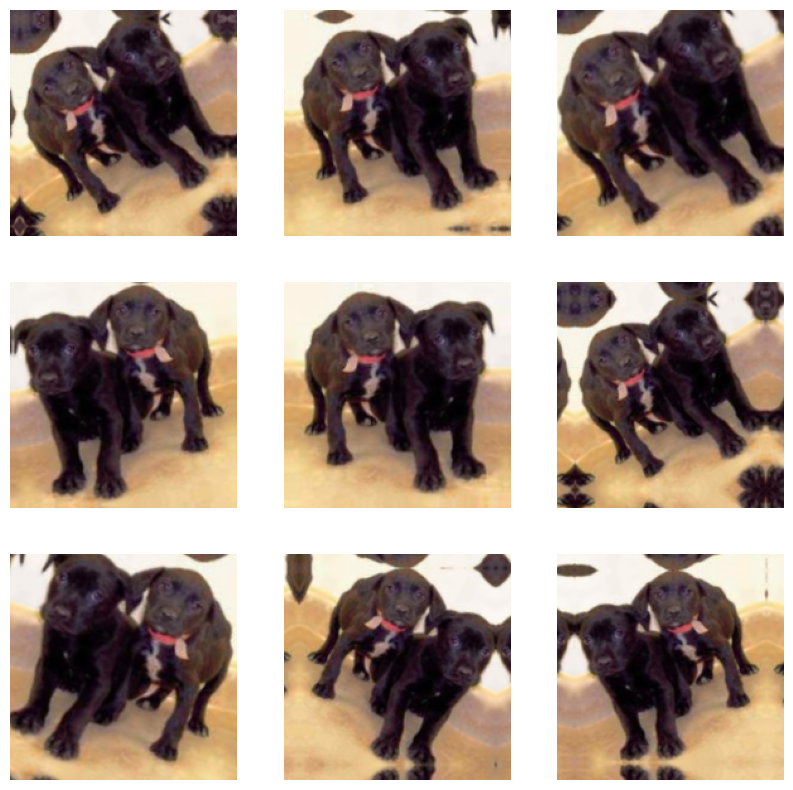

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3,3,i+1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

In [21]:
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

In [22]:
callbacks = [
 keras.callbacks.ModelCheckpoint(
 filepath="convnet_from_scratch_with_augmentation.keras",
 save_best_only=True,
 monitor="val_loss")
]
history = model.fit(
                  train_ds,
                  epochs=100,
                  validation_data=validation_ds,
                  callbacks=callbacks)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.4905 - loss: 0.7175 - val_accuracy: 0.5000 - val_loss: 0.6949
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.5075 - loss: 0.6971 - val_accuracy: 0.6130 - val_loss: 0.6927
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.5130 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6940
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5125 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.7876
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.5525 - loss: 0.6929 - val_accuracy: 0.6300 - val_loss: 0.6536
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.6095 - loss: 0.6703 - val_accuracy: 0.6240 - val_loss: 0.6467
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.6330 - loss: 0.6453 - val_accuracy: 0.6250 - val_loss: 0.6460
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.6545 - loss: 0.6276 - val_accuracy: 0.

In [23]:
test_model = keras.models.load_model("convnet_from_scratch_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8210 - loss: 0.4148
Test accuracy: 0.821


In [24]:
from tensorflow.keras.applications import vgg16

conv_base = vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180,180,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [25]:
conv_base.trainable = False

In [26]:
inputs = keras.Input(shape=(180,180,3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256,activation='sigmoid')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1,activation='sigmoid')(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(loss="binary_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

In [27]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_transfer_learning.keras",
        save_best_only=True,
        monitor="val_accuracy"
    )
]

In [28]:
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=validation_ds,
    callbacks=callbacks
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 230ms/step - accuracy: 0.9165 - loss: 0.2107 - val_accuracy: 0.9760 - val_loss: 0.0683
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 183ms/step - accuracy: 0.9515 - loss: 0.1137 - val_accuracy: 0.9750 - val_loss: 0.0557
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 168ms/step - accuracy: 0.9635 - loss: 0.0869 - val_accuracy: 0.9760 - val_loss: 0.0562
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.9690 - loss: 0.0761 - val_accuracy: 0.9760 - val_loss: 0.0525
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 169ms/step - accuracy: 0.9780 - loss: 0.0678 - val_accuracy: 0.9750 - val_loss: 0.0531
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.9765 - loss: 0.0623 - val_accuracy: 0.9790 - val_loss: 0.0507
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.9785 - loss: 0.0560 - val_accuracy: 0.9780 - val_loss: 0.0484
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.9785 - loss: 0.0514 - val_accu

In [29]:
test_model = keras.models.load_model("convnet_transfer_learning.keras")
test_loss, test_acc = test_model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - accuracy: 0.9760 - loss: 0.0756
Test accuracy: 0.976


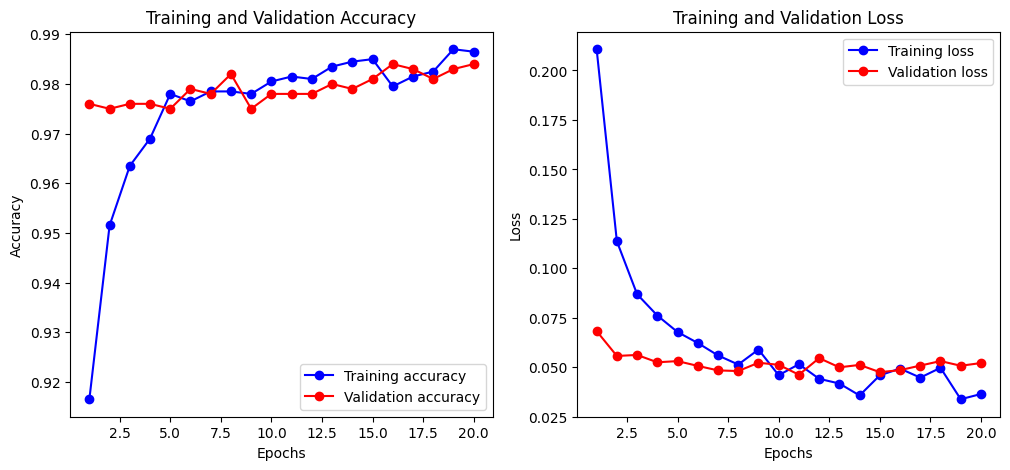

In [30]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, "bo-", label="Training accuracy")
plt.plot(epochs, val_accuracy, "ro-", label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "bo-", label="Training loss")
plt.plot(epochs, val_loss, "ro-", label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [31]:
!pip install gradio -q

In [32]:
import gradio as gr
import numpy as np
from tensorflow import keras
import tensorflow as tf

# Best saved model load karein
model = keras.models.load_model("convnet_transfer_learning.keras")

def predict_image(img):
    # Image ko model ke input size (180x180) mein resize karein
    img = tf.image.resize(img, (180, 180))
    img_array = tf.expand_dims(img, 0)  # batch dimension add karein (1, 180, 180, 3)

    # Prediction
    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        label = "Dog 🐶"
        confidence = prediction
    else:
        label = "Cat 🐱"
        confidence = 1 - prediction

    return f"{label} ({confidence*100:.1f}% confident)"

# Gradio interface
demo = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="numpy", label="Image upload karein"),
    outputs=gr.Textbox(label="Prediction"),
    title="Cat vs Dog Classifier",
    description="Koi bhi cat ya dog ki image upload karein, model bata dega konsa hai."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b22be6a73bf85601f4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
